In [1]:
!pip install tensorflow matplotlib seaborn scikit-learn Pillow -q

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt
import os
import numpy as np

# **Data Loading**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH ='/content/drive/MyDrive/landmark2'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Data Split**

In [4]:
# train 80%
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# validation 20%
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 564 files belonging to 4 classes.
Using 452 files for training.
Found 564 files belonging to 4 classes.
Using 112 files for validation.


# **Data Augmentation**

In [5]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomContrast(0.1), ])

# **Model**

In [6]:
base_model = tf.keras.applications.ConvNeXtTiny(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3))

base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=5e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# **Class** Weights

In [7]:
# class_counts = [71, 156, 156, 141, 43, 165]
class_counts = [ 156, 156, 141, 165]
total_images = sum(class_counts)
class_weights = {i: total_images / (len(class_counts) * count) for i, count in enumerate(class_counts)}

print("Class Weights:", class_weights)

Class Weights: {0: 0.9903846153846154, 1: 0.9903846153846154, 2: 1.0957446808510638, 3: 0.9363636363636364}


# Training

In [8]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('luxora_v2.h5', save_best_only=True, monitor='val_accuracy'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 918ms/step - accuracy: 0.2562 - loss: 1.9268

15/15 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.2699 - loss: 1.8793 - val_accuracy: 0.2411 - val_loss: 1.5645 - learning_rate: 5.0000e-06
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 641ms/step - accuracy: 0.3252 - loss: 1.6315 - val_accuracy: 0.2411 - val_loss: 1.5140 - learning_rate: 5.0000e-06
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 665ms/step - accuracy: 0.3562 - loss: 1.5047 - val_accuracy: 0.2411 - val_loss: 1.4675 - learning_rate: 5.0000e-06
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 660ms/step - accuracy: 0.4226 - loss: 1.3157 - val_accuracy: 0.2411 - val_loss: 1.4277 - learning_rate: 5.0000e-06
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 676ms/step - accuracy: 0.4358 - loss: 1.3181 - val_accuracy: 0.2321 - val_loss: 1.3932 - learning_rate: 5.0000e-06
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 691ms/step - accuracy: 0.5199 - loss: 1.1695 - val_accuracy: 0.2321 - val_loss: 1.3606 - learning_rate: 5.0000e-06
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 708ms/step - accuracy: 0.5088

15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 764ms/step - accuracy: 0.5796 - loss: 1.0725 - val_accuracy: 0.2589 - val_loss: 1.3021 - learning_rate: 5.0000e-06
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.5241 - loss: 1.0746

15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 749ms/step - accuracy: 0.5288 - loss: 1.0792 - val_accuracy: 0.3036 - val_loss: 1.2772 - learning_rate: 5.0000e-06
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.5704 - loss: 1.0482

15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 742ms/step - accuracy: 0.5819 - loss: 1.0044 - val_accuracy: 0.3571 - val_loss: 1.2516 - learning_rate: 5.0000e-06
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.5934 - loss: 0.9433

...

15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 749ms/step - accuracy: 0.6969 - loss: 0.7048 - val_accuracy: 0.7321 - val_loss: 0.9114 - learning_rate: 5.0000e-06
Epoch 24/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 698ms/step - accuracy: 0.7456 - loss: 0.6435 - val_accuracy: 0.7321 - val_loss: 0.8852 - learning_rate: 5.0000e-06
Epoch 25/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 697ms/step - accuracy: 0.7102 - loss: 0.6730 - val_accuracy: 0.7321 - val_loss: 0.8584 - learning_rate: 5.0000e-06
Epoch 26/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.7608 - loss: 0.6426

15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 746ms/step - accuracy: 0.7412 - loss: 0.6413 - val_accuracy: 0.7411 - val_loss: 0.8334 - learning_rate: 5.0000e-06
Epoch 27/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.7054 - loss: 0.6822

15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 794ms/step - accuracy: 0.7434 - loss: 0.6471 - val_accuracy: 0.7589 - val_loss: 0.8063 - learning_rate: 5.0000e-06
Epoch 28/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 693ms/step - accuracy: 0.7522 - loss: 0.6180 - val_accuracy: 0.7589 - val_loss: 0.7774 - learning_rate: 5.0000e-06
Epoch 29/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 695ms/step - accuracy: 0.7743 - loss: 0.5930 - val_accuracy: 0.7589 - val_loss: 0.7525 - learning_rate: 5.0000e-06
Epoch 30/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 696ms/step - accuracy: 0.7212 - loss: 0.6577 - val_accuracy: 0.7589 - val_loss: 0.7295 - learning_rate: 5.0000e-06
Epoch 31/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 696ms/step - accuracy: 0.7588 - loss: 0.6119 - val_accuracy: 0.7500 - val_loss: 0.7095 - learning_rate: 5.0000e-06
Epoch 32/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 698ms/step - accuracy: 0.7788 - loss: 0.5570 - val_accuracy: 0.7589 - val_loss: 0.6879 - learning_rate: 5.0000e-06
Epoch 33/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy:

15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 766ms/step - accuracy: 0.7566 - loss: 0.6071 - val_accuracy: 0.7679 - val_loss: 0.6677 - learning_rate: 5.0000e-06
Epoch 34/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 692ms/step - accuracy: 0.7434 - loss: 0.5616 - val_accuracy: 0.7679 - val_loss: 0.6563 - learning_rate: 5.0000e-06
Epoch 35/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.7398 - loss: 0.6079

15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 747ms/step - accuracy: 0.7566 - loss: 0.5593 - val_accuracy: 0.8036 - val_loss: 0.6480 - learning_rate: 5.0000e-06
Epoch 36/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 733ms/step - accuracy: 0.8009 - loss: 0.5334 - val_accuracy: 0.7857 - val_loss: 0.6255 - learning_rate: 5.0000e-06
Epoch 37/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 696ms/step - accuracy: 0.8097 - loss: 0.5021 - val_accuracy: 0.7857 - val_loss: 0.6075 - learning_rate: 5.0000e-06
Epoch 38/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 698ms/step - accuracy: 0.7942 - loss: 0.5186 - val_accuracy: 0.7768 - val_loss: 0.5861 - learning_rate: 5.0000e-06
Epoch 39/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 701ms/step - accuracy: 0.7854 - loss: 0.5140 - val_accuracy: 0.7946 - val_loss: 0.5797 - learning_rate: 5.0000e-06
Epoch 40/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 698ms/step - accuracy: 0.8119 - loss: 0.5048 - val_accuracy: 0.8036 - val_loss: 0.5746 - learning_rate: 5.0000e-06
Epoch 41/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 696ms/step - accuracy

In [9]:
for images, labels in train_ds.take(1):
    print(f"Shape of labels in train_ds: {labels.shape}")
    print(f"Number of classes in train_ds: {labels.shape[-1]}")

Shape of labels in train_ds: (32, 4)
Number of classes in train_ds: 4


# **Confusion Matrix**

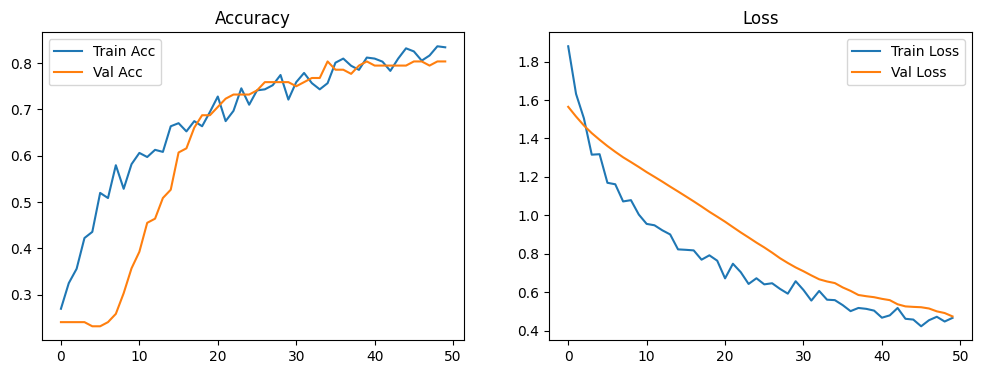

In [10]:
def plot_luxora_results(history):
    plt.figure(figsize=(12, 4))
    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy')
    plt.legend()
    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()

plot_luxora_results(history)

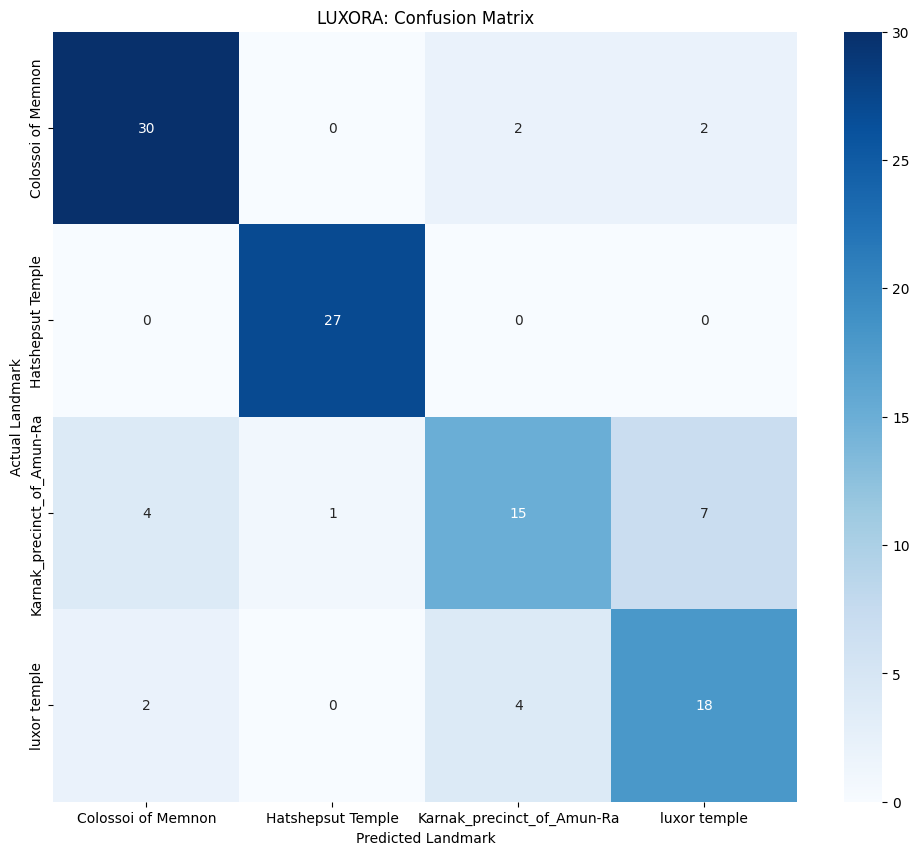


Classification Report:
                            precision    recall  f1-score   support

        Colossoi of Memnon       0.83      0.88      0.86        34
         Hatshepsut Temple       0.96      1.00      0.98        27
Karnak_precinct_of_Amun-Ra       0.71      0.56      0.62        27
              luxor temple       0.67      0.75      0.71        24

                  accuracy                           0.80       112
                 macro avg       0.79      0.80      0.79       112
              weighted avg       0.80      0.80      0.80       112



In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# class_names = ['Abu_Haggag_Mosque', 'Colossoi of Memnon', 'Hatshepsut Temple',
#                'Karnak_precinct_of_Amun-Ra', 'Luxor_Museum', 'luxor temple']


class_names = [ 'Colossoi of Memnon', 'Hatshepsut Temple',
               'Karnak_precinct_of_Amun-Ra', 'luxor temple']

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('LUXORA: Confusion Matrix')
plt.ylabel('Actual Landmark')
plt.xlabel('Predicted Landmark')
plt.show()

print("\nClassification Report:")
unique_labels_in_val_ds = np.unique(y_true)
filtered_class_names = [class_names[i] for i in unique_labels_in_val_ds]
print(classification_report(y_true, y_pred, target_names=filtered_class_names, labels=unique_labels_in_val_ds))

# **Testing**

Saving 12.jpg to 12.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


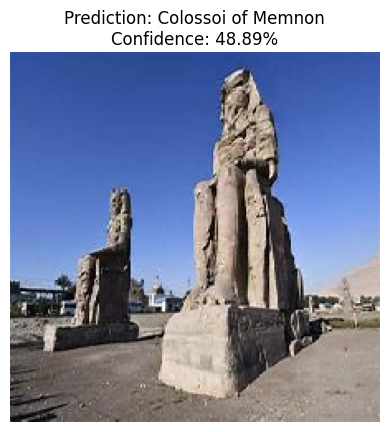

 48.89%  this is Colossoi of Memnon


In [26]:
import numpy as np
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array

# class_names = ['Abu_Haggag_Mosque', 'Colossoi of Memnon', 'Hatshepsut Temple',
#                'Karnak_precinct_of_Amun-Ra', 'Luxor_Museum', 'luxor temple']

class_names = [ 'Colossoi of Memnon', 'Hatshepsut Temple',
               'Karnak_precinct_of_Amun-Ra', 'luxor temple']


def predict_uploaded_image(model):
    uploaded = files.upload()

    for filename in uploaded.keys():
        img = load_img(filename, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)

        # Predection
        predictions = model.predict(img_array)
        score = tf.nn.softmax(predictions[0])

        predicted_class = class_names[np.argmax(predictions)]
        confidence = 100 * np.max(predictions)

        # result
        plt.imshow(img)
        plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
        plt.axis('off')
        plt.show()

        print(f" {confidence:.2f}%  this is {predicted_class}")

predict_uploaded_image(model)

In [13]:
# import numpy as np
# import tensorflow as tf
# from google.colab import files
# from tensorflow.keras.utils import load_img, img_to_array
# import matplotlib.pyplot as plt

# class_names = ['Colossoi of Memnon', 'Hatshepsut Temple',
#                'Karnak_precinct_of_Amun-Ra', 'luxor temple']

# def predict_uploaded_image_with_tta(model):
#     uploaded = files.upload()

#     for filename in uploaded.keys():
#         img = load_img(filename, target_size=(224, 224))
#         img_array = img_to_array(img)
#         img_array = np.expand_dims(img_array, axis=0)
#         img_array = img_array / 255.0

#         #TTA
#         tta_predictions = []
#         tta_predictions.append(model.predict(img_array))
#         tta_predictions.append(model.predict(tf.image.flip_left_right(img_array)))
#         tta_predictions.append(model.predict(tf.image.adjust_brightness(img_array, 0.1)))
#         tta_predictions.append(model.predict(tf.image.adjust_contrast(img_array, 1.2)))
#         tta_predictions.append(model.predict(tf.image.central_crop(img_array, 0.9)))
#         final_prediction = np.mean(tta_predictions, axis=0)

#         #predection
#         predicted_class = class_names[np.argmax(final_prediction)]
#         confidence = 100 * np.max(final_prediction)

#         #result
#         plt.imshow(img)
#         plt.title(f"TTA Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
#         plt.axis('off')
#         plt.show()

#         print(f"Confidence: {confidence:.2f}% | This is {predicted_class}")

# predict_uploaded_image_with_tta(model)

# **Save Model**

In [14]:
model.save('Luxora_Final_Model_v1.keras')
model.save('Luxora_Final_Model_v1.h5')

In [15]:
import tensorflow as tf
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('luxora_model.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpl8xnlv5g'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_163')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137682960581456: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  137682960582032: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  137682960584336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137682960584912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137682960585680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137682960586448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137682960586256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137682960585872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137682960584720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137682960586064: TensorSpec(shape=(), dtype=tf.resource, name=